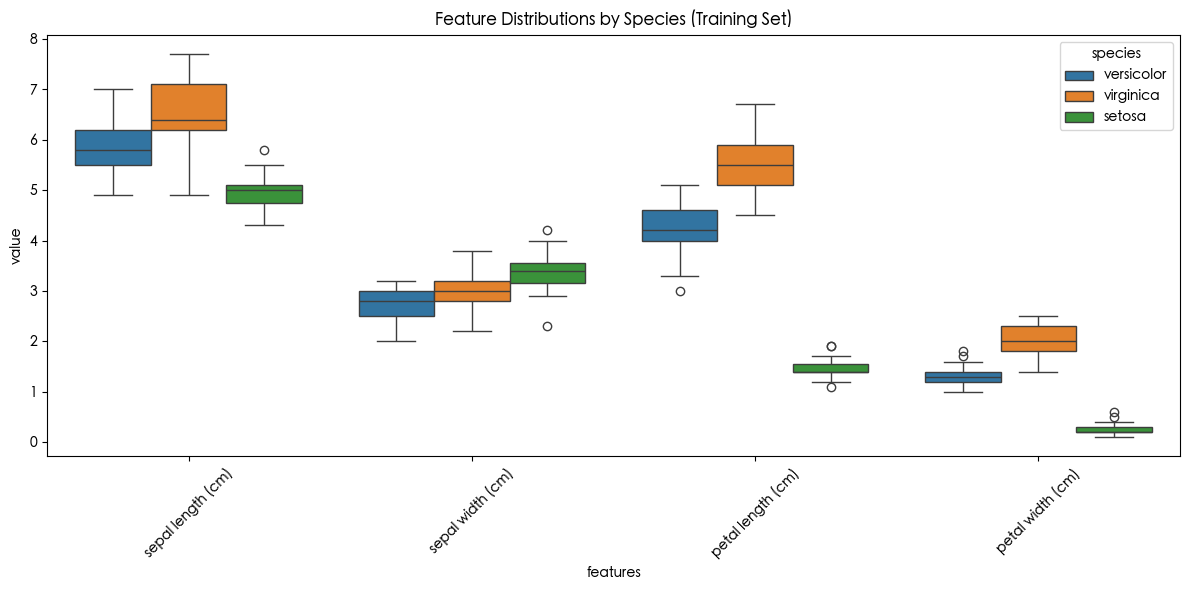

<Figure size 800x600 with 0 Axes>

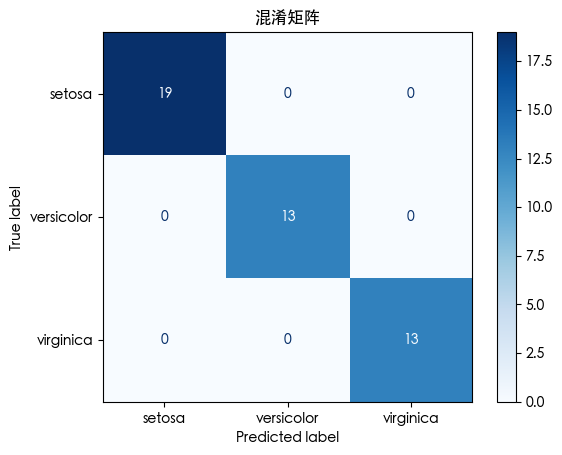

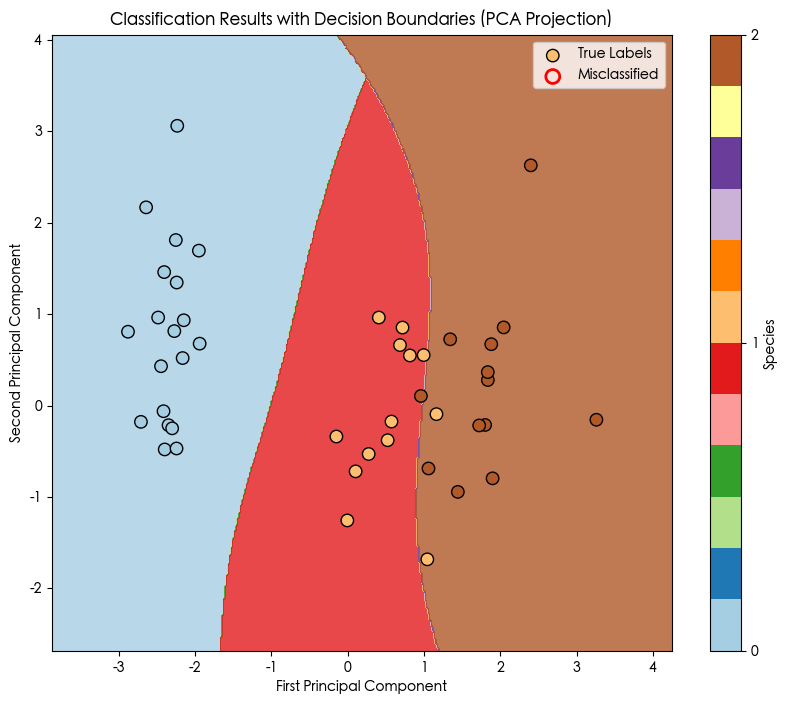


Model Performance Metrics:
Accuracy: 1.0000

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        19
  versicolor       1.00      1.00      1.00        13
   virginica       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45



In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.decomposition import PCA
from matplotlib import rcParams

# 配置 matplotlib 使用字体
rcParams['font.sans-serif'] = ['Heiti TC']
rcParams['axes.unicode_minus'] = False  # 解决负号显示问题

# 加载数据集
iris = datasets.load_iris()
X = iris.data
y = iris.target
target_names = iris.target_names

# 数据集划分
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# ================== 数据可视化 ==================
# 1. 特征分布箱线图（使用原始数据）
plt.figure(figsize=(12, 6))
df_train = pd.DataFrame(X_train, columns=iris.feature_names)
df_train["species"] = [target_names[y] for y in y_train]
melt_df = df_train.melt(id_vars="species", var_name="features", value_name="value")
plt.title("Feature Distributions by Species (Training Set)")
sns.boxplot(x="features", y="value", hue="species", data=melt_df)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 数据标准化
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# ================== 模型训练 ==================
model = SVC(kernel="rbf", C=1.0, gamma="scale", random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# ================== 模型评估可视化 ==================
# 1. 混淆矩阵
plt.figure(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, display_labels=target_names, cmap="Blues"
)
plt.title("混淆矩阵")
plt.show()

# 2. 分类结果PCA可视化
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

# 创建决策边界网格
x_min, x_max = X_test_pca[:, 0].min() - 1, X_test_pca[:, 0].max() + 1
y_min, y_max = X_test_pca[:, 1].min() - 1, X_test_pca[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02), np.arange(y_min, y_max, 0.02))

# 预测网格点类别（使用原始模型）
Z = model.predict(pca.inverse_transform(np.c_[xx.ravel(), yy.ravel()]))
Z = Z.reshape(xx.shape)

plt.figure(figsize=(10, 8))
plt.contourf(xx, yy, Z, alpha=0.8, cmap=plt.cm.Paired)
scatter = plt.scatter(
    X_test_pca[:, 0],
    X_test_pca[:, 1],
    c=y_test,
    edgecolors="k",
    cmap=plt.cm.Paired,
    s=80,
    label="True Labels",
)
# 标记错误分类点
errors = np.where(y_pred != y_test)
plt.scatter(
    X_test_pca[errors, 0],
    X_test_pca[errors, 1],
    s=100,
    edgecolors="red",
    facecolors="none",
    linewidths=2,
    label="Misclassified",
)

plt.xlabel("First Principal Component")
plt.ylabel("Second Principal Component")
plt.title("Classification Results with Decision Boundaries (PCA Projection)")
plt.legend()
plt.colorbar(scatter, ticks=[0, 1, 2], label="Species")
plt.show()

# 输出性能指标
print("\n" + "="*40)
print("Model Performance Metrics:")
print("="*40)
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=target_names))